# Netflix Data Analysis
Exploring trends in genres, ratings, release years, and countries across Netflix's movie & TV show catalog.

**Dataset:** Netflix Movies and TV Shows (Kaggle)

**Tools:** Python, Pandas, Matplotlib

# Table of Contents

1. Project Overview
2. Dataset
3. Import Libraries
4. Data Cleaning
5. Feature Engineering
6. Exploratory Data Analysis
7. Key Insights
8. Summary

## Skills Demonstrated

- Python

- Pandas

- Data Cleaning

- Feature Engineering

- Exploratory Data Analysis

- Data Visualization

- Matplotlib

- Business Insight Generation

## 1. Imports & Setup

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Nicer default look for charts
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

pd.set_option('display.max_columns', None)

## 2. Load the Data

In [5]:
df = pd.read_csv('data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. Initial Exploration

In [6]:
print("Shape:", df.shape)
df.info()

Shape: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Missing values per column, sorted, only columns with at least 1 missing value
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

director      2634
country        831
cast           825
date_added      10
rating           4
duration         3
dtype: int64

## 4. Data Cleaning

In [9]:
df_clean = df.copy()

# 4.1 Fill missing text fields
for col in ['director', 'cast', 'country']:
    df_clean[col] = df_clean[col].fillna('Unknown')
    

# Drop the handful of rows missing essentials we can't reasonably fill
df_clean = df_clean.dropna(subset=['date_added', 'rating'])

# 4.2 Convert date_added to datetime
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip(), errors='coerce')
df_clean = df_clean.dropna(subset=['date_added'])

df_clean[['director', 'cast', 'country', 'date_added']].isnull().sum()

director      0
cast          0
country       0
date_added    0
dtype: int64

In [12]:
# 4.3 Split duration into a numeric column, handled separately for Movies vs TV Shows
def parse_duration(row):
    if pd.isna(row['duration']):
        return None
    return int(str(row['duration']).split(' ')[0])

df_clean['duration_value'] = df_clean.apply(parse_duration, axis=1)
df_clean['duration_unit'] = df_clean['type'].map({'Movie': 'min', 'TV Show': 'seasons'})

df_clean[['type', 'duration', 'duration_value', 'duration_unit']].head()

,type,duration,duration_value,duration_unit
0,Movie,90 min,90.0,min
1,TV Show,2 Seasons,2.0,seasons
2,TV Show,1 Season,1.0,seasons
3,TV Show,1 Season,1.0,seasons
4,TV Show,2 Seasons,2.0,seasons


In [13]:
# 4.4 Explode multi-value columns: genres and country
df_genres = df_clean.assign(genre=df_clean['listed_in'].str.split(', ')).explode('genre')
df_countries = df_clean.assign(country_single=df_clean['country'].str.split(', ')).explode('country_single')

print("Original rows:", len(df_clean))
print("Rows after exploding genres:", len(df_genres))
print("Rows after exploding countries:", len(df_countries))

Original rows: 8793
Rows after exploding genres: 19297
Rows after exploding countries: 10831


## 5. Feature Engineering

In [15]:
print(df_clean['date_added'].dtype)

object


In [16]:
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')

In [17]:
df_clean = df_clean.dropna(subset=['date_added'])

In [18]:
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month_name()

# How many years after release did the title get added to Netflix?
df_clean['years_to_add'] = df_clean['year_added'] - df_clean['release_year']

df_clean[['title', 'release_year', 'year_added', 'years_to_add']].head()

,title,release_year,year_added,years_to_add
0,Dick Johnson Is Dead,2020,2021,1
1,Blood & Water,2021,2021,0
2,Ganglands,2021,2021,0
3,Jailbirds New Orleans,2021,2021,0
4,Kota Factory,2021,2021,0


## Dataset Size
**Titles: 8,797**

**Movies: 6,129**

**TV Shows: 2,576**

**Countries: 748**

**Genres: 42+**

**Years Covered:
1925–2021**

## 6. Exploratory Analysis & Visualization
Each chart below is built around one specific question, followed by a short interpretation.

### 6.1 Movies vs TV Shows — what dominates the catalog?

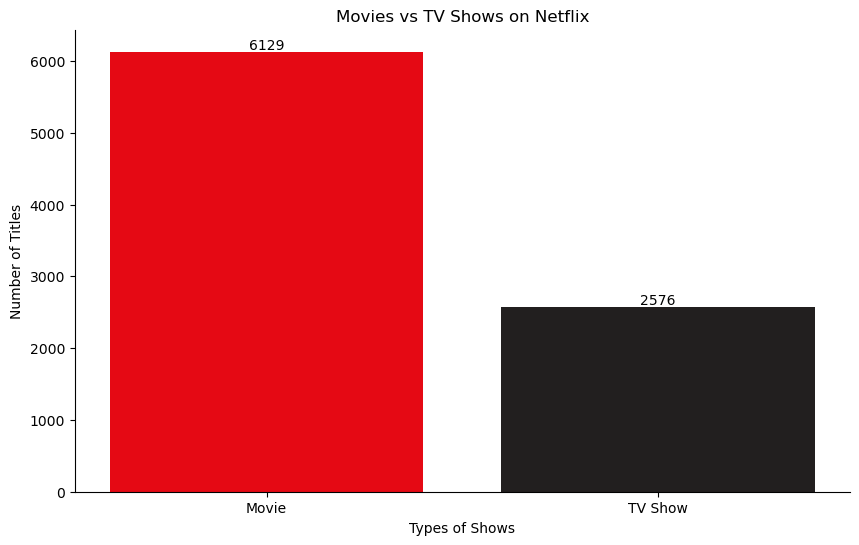

In [30]:
import os
os.makedirs('images', exist_ok=True)

type_counts = df_clean['type'].value_counts()

fig, ax = plt.subplots()
ax.bar(type_counts.index, type_counts.values, color=['#E50914', '#221f1f'])
ax.set_title('Movies vs TV Shows on Netflix')
ax.set_ylabel('Number of Titles')
ax.set_xlabel( 'Types of Shows' )

for i, v in enumerate(type_counts.values):
    ax.text(i, v + 30, str(v), ha='center')

plt.savefig('images/01_type_counts.png', dpi=150, bbox_inches='tight')
plt.show()

## Insights from the Bar Graph: Movies vs TV Shows on Netflix

- **Movies dominate the Netflix catalogue:** There are **6,129 Movies** compared to **2,576 TV Shows**.
- **Movies are the primary content type:** Netflix offers considerably more Movies than TV Shows in this dataset.
- **The ratio is approximately 2.4:1:** For every TV Show, there are about **2.4 Movies**.
- **TV Shows still represent a significant portion:** Although fewer in number, TV Shows make up an important part of Netflix's catalogue.
- **Content distribution:** The dataset indicates that Netflix has historically maintained a larger collection of Movies than TV Shows.

### Conclusion
The chart shows that **Movies are the dominant content type on Netflix**, while **TV Shows form a smaller but still substantial share of the catalogue**.

### 6.2 Content Growth Over Time — how fast has the catalog grown?

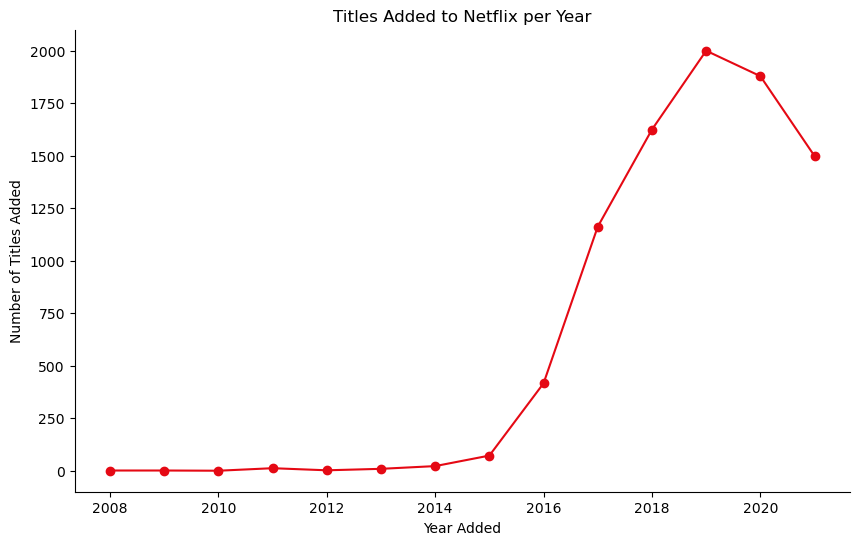

In [21]:
yearly = df_clean['year_added'].value_counts().sort_index()

fig, ax = plt.subplots()
ax.plot(yearly.index, yearly.values, marker='o', color='#E50914')
ax.set_title('Titles Added to Netflix per Year')
ax.set_xlabel('Year Added')
ax.set_ylabel('Number of Titles Added')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.savefig('images/02_titles_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

## Insights from the Line Graph: Titles Added to Netflix per Year

- **Content additions remained very low between 2008 and 2015**, indicating that Netflix had a relatively small catalogue during its early years.
- **A sharp increase begins in 2016**, showing a major expansion in Netflix's content library.
- **The number of titles added continued to grow rapidly from 2016 to 2019**, reflecting Netflix's global expansion and increased investment in Movies and TV Shows.
- **2019 recorded the highest number of titles added (around 2,000)**, making it the peak year in this dataset.
- **After 2019, the number of new titles added declined slightly in 2020 and 2021.** This may indicate slower content additions or that the dataset does not contain all titles released during the latest years.

### Conclusion

The graph shows that Netflix experienced rapid growth in its content catalogue from 2016 onwards, reaching its highest level of content additions in 2019. Although additions decreased slightly after the peak, Netflix continued to add a large number of titles each year.

### 6.3 Top 10 Genres — what content categories dominate?

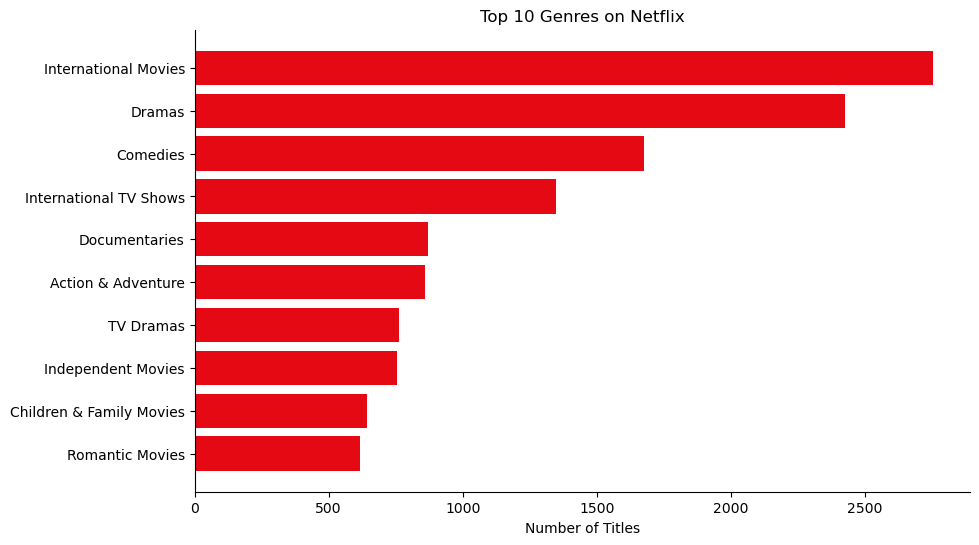

In [22]:
top_genres = df_genres['genre'].value_counts().head(10)

fig, ax = plt.subplots()
ax.barh(top_genres.index[::-1], top_genres.values[::-1], color='#E50914')
ax.set_title('Top 10 Genres on Netflix')
ax.set_xlabel('Number of Titles')
plt.savefig('images/03_top_genres.png', dpi=150, bbox_inches='tight')
plt.show()

## Insights from the Bar Chart: Top 10 Genres on Netflix

- **International Movies are the most common genre** on Netflix, indicating the platform's strong focus on offering content from different countries and cultures.
- **Dramas rank second**, showing that dramatic content is one of the most popular categories in Netflix's catalogue.
- **Comedies hold the third position**, suggesting that light-hearted and entertaining content is also highly represented.
- **International TV Shows** appear among the top genres, highlighting Netflix's investment in global television content alongside movies.
- Genres such as **Documentaries**, **Action & Adventure**, **TV Dramas**, and **Independent Movies** have a moderate presence, providing viewers with a diverse range of content.
- **Children & Family Movies** and **Romantic Movies** are included in the top 10 but have comparatively fewer titles than the leading genres.
- Overall, the distribution shows that Netflix maintains a **diverse content library**, while placing greater emphasis on internationally produced movies and drama-based entertainment.
### Conclusion

The graph indicates that Netflix's catalogue is strongly focused on **International Movies, Dramas, and Comedies**, reflecting its strategy of providing diverse, globally accessible content while catering to a wide variety of audience preferences.

### 6.4 Top 10 Producing Countries

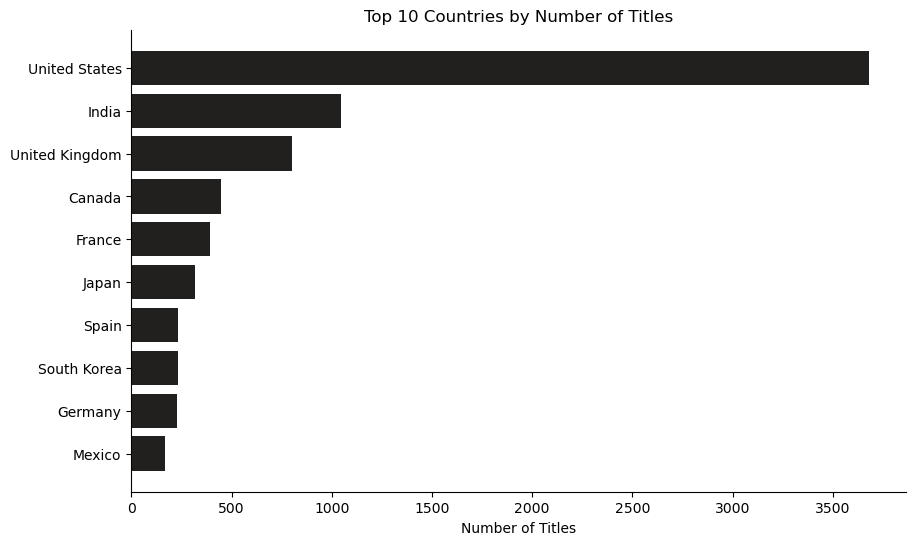

In [23]:
top_countries = (df_countries[df_countries['country_single'] != 'Unknown']
                  ['country_single'].value_counts().head(10))

fig, ax = plt.subplots()
ax.barh(top_countries.index[::-1], top_countries.values[::-1], color='#221f1f')
ax.set_title('Top 10 Countries by Number of Titles')
ax.set_xlabel('Number of Titles')
plt.savefig('images/04_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()

## Insights from the Bar Chart: Top 10 Countries by Number of Titles

- **The United States contributes the largest number of titles** to Netflix's catalogue, significantly outperforming all other countries.
- **India ranks second**, demonstrating its strong presence as one of Netflix's major content-producing markets.
- **The United Kingdom holds the third position**, followed by Canada, France, and Japan.
- Countries such as **Spain, South Korea, Germany, and Mexico** also contribute to the catalogue, although with considerably fewer titles.
- The large difference between the United States and the remaining countries indicates that Netflix's content library is heavily influenced by American productions.
- The inclusion of countries from different continents highlights Netflix's commitment to offering diverse international content.
### Conclusion
The graph shows that the **United States dominates Netflix's content catalogue**, while countries such as India and the United Kingdom also make significant contributions. Overall, Netflix maintains a globally diverse library, although content production is concentrated in a few leading countries.

### 6.5 Content Rating Distribution — who is Netflix's catalog made for?

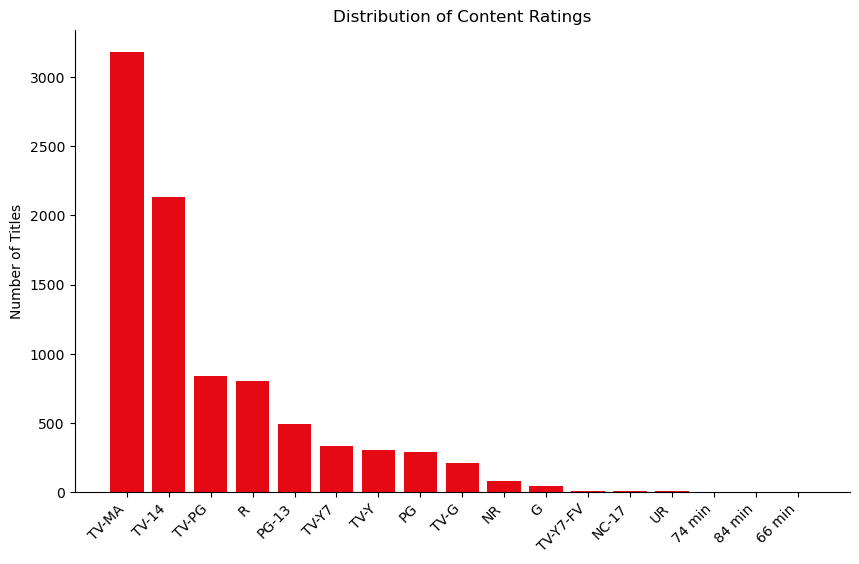

In [35]:
rating_counts = df_clean['rating'].value_counts()

fig, ax = plt.subplots()
ax.bar(rating_counts.index, rating_counts.values, color='#E50914')
ax.set_title('Distribution of Content Ratings')
ax.set_ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.savefig('05_content_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

## Insights from the Bar Chart: Distribution of Content Ratings

- **TV-MA is the most common content rating**, indicating that a large portion of Netflix's catalogue is intended for mature audiences.
- **TV-14 ranks second**, suggesting that Netflix also offers a substantial amount of content suitable for teenagers and older viewers.
- Ratings such as **TV-PG, R, and PG-13** have a moderate presence, providing options for family and general audiences.
- **Children's ratings**, including **TV-Y, TV-Y7, and G**, represent a smaller share of the catalogue compared to adult-oriented content.
- A few uncommon ratings, such as **NC-17, UR**, and entries like **74 min, 84 min, and 66 min**, appear only a small number of times. These duration values likely indicate **data quality issues or incorrectly recorded rating values** in the dataset.
- Overall, the rating distribution suggests that Netflix primarily focuses on producing and acquiring content for **adult and teenage audiences**.

### Conclusion

The visualization indicates that Netflix's catalogue is largely targeted towards **mature and teenage viewers**, with **TV-MA** and **TV-14** being the dominant content ratings. Family-friendly and children's content is available but represents a smaller portion of the overall library.
### Note
A few entries in the rating column contain duration values (e.g., 74 min, 84 min, and 66 min) instead of valid content ratings. These appear to be data entry inconsistencies in the original dataset and have a minimal impact on the overall analysis

### 6.6 Release Year Distribution — is Netflix mostly recent content or a mix of eras?

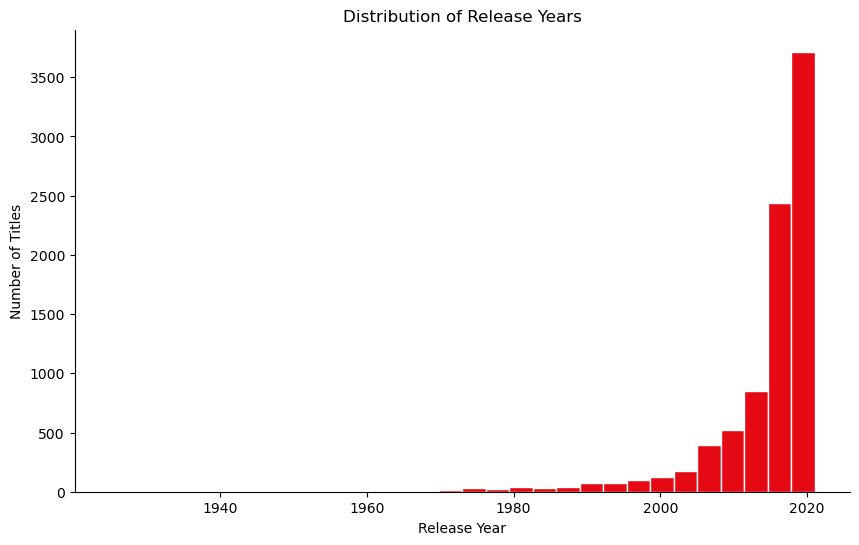

In [25]:
fig, ax = plt.subplots()
ax.hist(df_clean['release_year'], bins=30, color='#E50914', edgecolor='white')
ax.set_title('Distribution of Release Years')
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Titles')
plt.savefig('images/06_release_year_hist.png', dpi=150, bbox_inches='tight')
plt.show()

## Insights from the Histogram: Distribution of Release Years

- **Most Netflix titles were released between 2015 and 2021**, indicating that the platform's catalogue is dominated by recently produced content.
- **The number of titles increases significantly after the year 2000**, showing a strong preference for modern movies and TV shows.
- **Very few titles were released before the 1980s**, suggesting that classic or older content makes up only a small portion of the catalogue.
- **The histogram is left-skewed (negatively skewed)**, with the majority of observations concentrated in the more recent release years and a long tail extending toward older years.
- The high concentration of recent titles reflects Netflix's strategy of acquiring and producing newer content to meet current audience preferences.

### Conclusion

The histogram demonstrates that Netflix's library is heavily focused on **modern content**, with the majority of titles released within the last decade. While older classics are present, they represent only a small fraction of the overall catalogue.

### 6.7 Genre Mix by Top Countries — do different countries favor different genres?

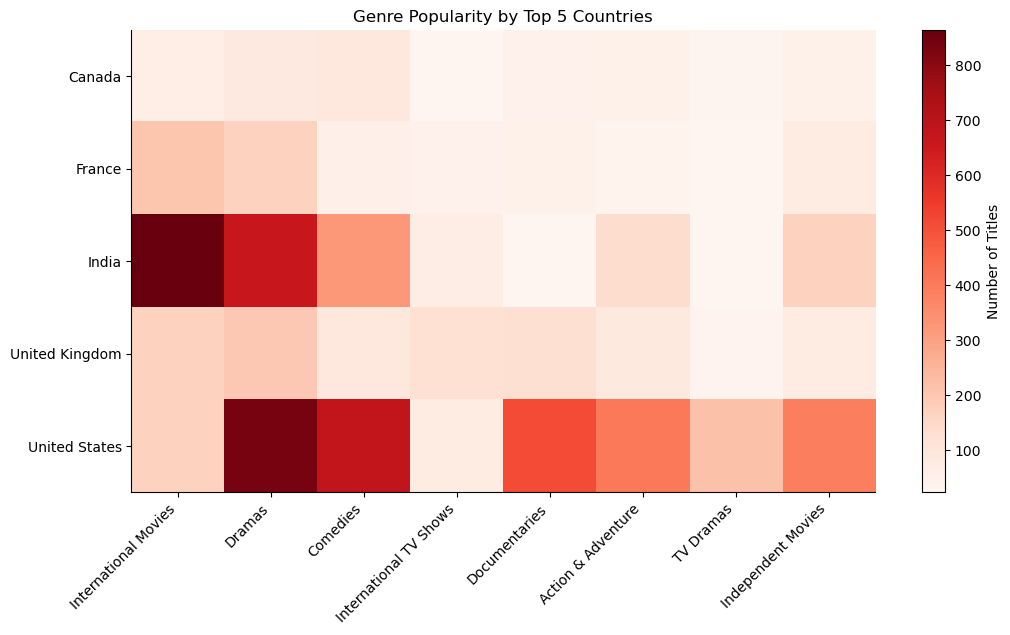

In [26]:
top5_countries = top_countries.head(5).index.tolist()

# Explode both country and genre on the same frame so each row is one (country, genre) pair
genre_country = (df_clean.assign(country_single=df_clean['country'].str.split(', '))
                  .explode('country_single')
                  .assign(genre=lambda d: d['listed_in'].str.split(', '))
                  .explode('genre')
                  .reset_index(drop=True))
genre_country = genre_country[genre_country['country_single'].isin(top5_countries)]
pivot = pd.crosstab(genre_country['country_single'], genre_country['genre'])

# Keep only the overall top 8 genres to keep the chart readable
top8_genre_cols = top_genres.head(8).index.tolist()
pivot = pivot[[c for c in top8_genre_cols if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(pivot.values, cmap='Reds', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title('Genre Popularity by Top 5 Countries')
fig.colorbar(im, ax=ax, label='Number of Titles')

plt.savefig('images/07_genre_by_country_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Insights from the Heatmap: Genre Popularity by Top 5 Countries

- **The United States has the highest number of titles across most genres**, particularly in **Dramas**, **Comedies**, and **Documentaries**, indicating a highly diverse content catalogue.
- **India shows a very strong presence in International Movies and Dramas**, with these genres having the highest intensity among all country-genre combinations.
- **The United Kingdom has a balanced distribution of titles** across multiple genres, although the overall counts are lower than those of the United States and India.
- **Canada and France contribute fewer titles overall**, with relatively lighter color intensity across most genres, indicating a smaller catalogue compared to the leading countries.
- **International TV Shows and TV Dramas have lower counts across all five countries**, suggesting that movies remain more dominant than television content within these major content-producing regions.
- The heatmap highlights that **genre popularity differs by country**, reflecting regional production strengths and audience preferences.
- Overall, **Dramas and International Movies are consistently popular across multiple countries**, making them two of Netflix's most prominent content categories.

### Conclusion

The heatmap reveals that the **United States and India dominate Netflix's catalogue** among the top five countries. While the United States offers a broad variety of genres, India has a particularly strong focus on **International Movies** and **Dramas**. This demonstrates Netflix's strategy of combining globally popular genres with region-specific content to appeal to diverse audiences.
> **Observation:** The heatmap makes it easy to compare multiple countries and genres simultaneously. Darker shades represent a higher number of titles, allowing viewers to quickly identify content concentration and regional genre preferences without examining multiple separate charts.

### 6.8 How Quickly Does Netflix Add New Releases?

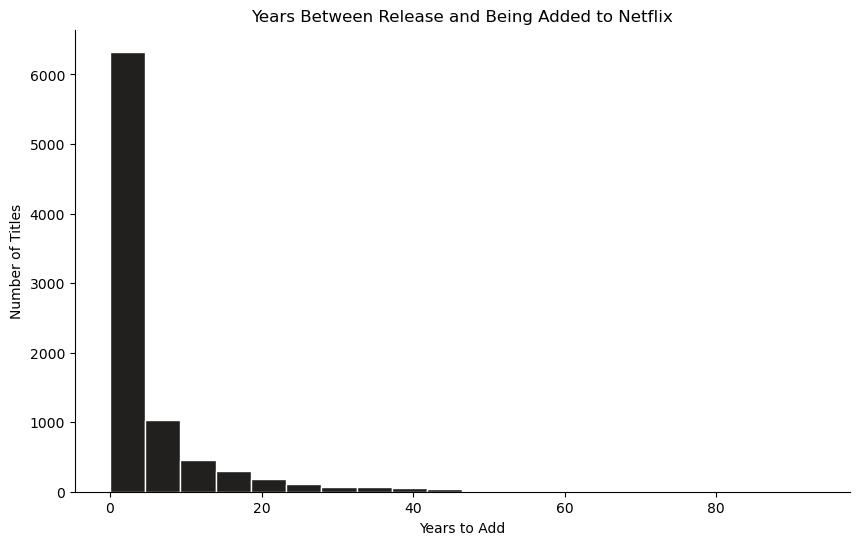

In [27]:
recent = df_clean[df_clean['years_to_add'] >= 0]

fig, ax = plt.subplots()
ax.hist(recent['years_to_add'], bins=20, color='#221f1f', edgecolor='white')
ax.set_title('Years Between Release and Being Added to Netflix')
ax.set_xlabel('Years to Add')
ax.set_ylabel('Number of Titles')
plt.savefig('images/08_years_to_add.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Insights

- **Most titles are added to Netflix very quickly after release:** The highest bar is concentrated between **0–5 years**, indicating that Netflix usually acquires or releases content within a few years of its original release.

- **Netflix focuses on recent content:** The large concentration of titles with a short waiting period suggests that Netflix prioritizes newer movies and TV shows over older ones.

- **Very old titles are relatively uncommon:** The number of titles decreases rapidly as the gap between release and Netflix addition increases, showing that only a small portion of the catalogue consists of older classics.

- **A long right tail is visible:** Some titles took **20–50+ years** to appear on Netflix, indicating that the platform occasionally licenses classic or older content.

- **The distribution is highly right-skewed:** Most observations are clustered near the lower values, while only a few titles have very large delays before being added.

- **Business Insight:** This pattern reflects Netflix's strategy of keeping its library fresh with recently released content while selectively adding older, evergreen titles to diversify the catalogue.

#  7. Summary of Findings

After analysing the Netflix Movies & TV Shows dataset, the following key insights were discovered:

**Movies dominate the Netflix catalogue**, accounting for approximately **70.4%** of all titles, while **TV Shows represent around 29.6%**. This indicates that Netflix places a stronger emphasis on movies than episodic content.

**Netflix experienced its fastest catalogue growth between 2017 and 2019**, with the highest number of titles added in **2019**. This rapid expansion reflects Netflix's aggressive global growth strategy and increased investment in content acquisition and original productions.

**The most popular genres are International Movies, Dramas, and Comedies**, showing that Netflix prioritises globally appealing content that attracts a wide and diverse audience across different regions.

**The United States is by far the largest contributor of content**, followed by **India** and the **United Kingdom**. This highlights Netflix's strong presence in North America while also demonstrating significant investment in international markets, particularly India.

**Most titles are rated TV-MA and TV-14**, indicating that Netflix's catalogue is primarily designed for mature and teenage audiences rather than young children.

**Most movies and TV shows are added to Netflix within the first few years after their release.** Only a small number of titles take decades to appear on the platform, suggesting that Netflix focuses on offering recent content while selectively adding classic titles.

**The release year distribution is heavily concentrated between 2015 and 2021**, showing that the majority of Netflix's catalogue consists of modern productions, with relatively fewer older titles.

**Genre popularity varies across countries.** While the United States has a balanced mix of genres, India shows particularly high numbers of International Movies and Dramas, reflecting regional content preferences and Netflix's localisation strategy.


## Overall Conclusion

This analysis shows that Netflix has built a **large, globally diverse, and modern content library**. The platform primarily focuses on **recent movies**, invests heavily in **international content**, and targets **teenage and adult audiences**. The combination of strong growth after 2016, dominance of global genres, and contributions from multiple countries demonstrates Netflix's evolution into one of the world's leading streaming platforms.

Netflix's catalogue is dominated by movies, with strong contributions from the United States and India. Most content has been added after 2016, reflecting Netflix's rapid global expansion.

The platform focuses primarily on recently released content, mature audiences, and internationally appealing genres such as Dramas and International Movies.

Overall, the analysis demonstrates Netflix's transition into a globally diverse streaming platform.

## Business Recommendations

Based on the analysis, the following recommendations can be made:

- Netflix should continue investing in International Movies, as they represent the largest genre in the catalog.
- India has emerged as one of the largest content-producing countries, indicating strong growth opportunities in the Asian market.
- Since TV-MA and TV-14 dominate the catalog, Netflix's content strategy primarily targets adult and teenage audiences.
- The rapid increase in titles after 2016 reflects Netflix's aggressive global expansion strategy.
- Most titles are added within a few years of release, showing Netflix prioritizes recent and trending content.